In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.insert(0, ".")

from dataset.coco_dataset import COCODataset, LABEL_TO_NAME
from dataset.transforms import get_train_transforms
from torch.utils.data import DataLoader
from dataset.coco_dataset import collate_fn

# ── Correct paths ─────────────────────────────────────────────────────────────
IMG_DIR  = r"D:\Projects\ODM Project\People_vehicles dataset\filtered_images"
ANN_FILE = r"D:\Projects\ODM Project\People_vehicles dataset\annotations\annotations_trainval2017\instances_train2017.json"

# ── Quick verify before loading ───────────────────────────────────────────────
print("IMG_DIR  exists:", os.path.exists(IMG_DIR))
print("ANN_FILE exists:", os.path.exists(ANN_FILE))
print("Images in folder:", len(os.listdir(IMG_DIR)))

IMG_DIR  exists: True
ANN_FILE exists: True
Images in folder: 70082


In [2]:
ds = COCODataset(IMG_DIR, ANN_FILE, transforms=get_train_transforms())
image, target = ds[0]

print("=== Single Sample Inspection ===")
print(f"Dataset size       : {len(ds)} images")
print(f"Image tensor shape : {image.shape}")
print(f"Image dtype        : {image.dtype}")
print(f"Image value range  : [{image.min():.2f}, {image.max():.2f}]")
print(f"Num boxes          : {len(target['boxes'])}")
print(f"Labels             : {[LABEL_TO_NAME[l.item()] for l in target['labels']]}")
print(f"Boxes sample       :\n{target['boxes'][:3]}")
print(f"Image ID           : {target['image_id'].item()}")

  Loading annotations from D:\Projects\ODM Project\People_vehicles dataset\annotations\annotations_trainval2017\instances_train2017.json ...
loading annotations into memory...
Done (t=8.25s)
creating index...
index created!
  Found 70082 images with target classes
=== Single Sample Inspection ===
Dataset size       : 70082 images
Image tensor shape : torch.Size([3, 640, 481])
Image dtype        : torch.float32
Image value range  : [-1.47, 2.30]
Num boxes          : 1
Labels             : ['person']
Boxes sample       :
tensor([[  2.8100, 162.8900, 313.4200, 628.0800]])
Image ID           : 36


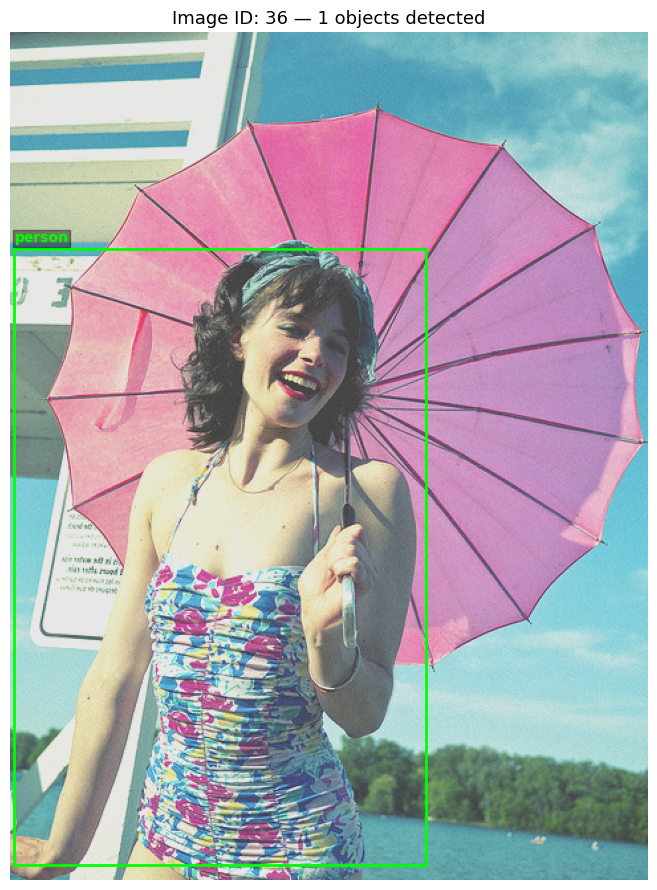

In [3]:
# De-normalise: undo ImageNet normalisation so image looks correct visually
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Colour per class
CLASS_COLORS = {
    "person":     "lime",
    "car":        "red",
    "truck":      "orange",
    "bus":        "cyan",
    "motorcycle": "magenta",
    "bicycle":    "yellow",
}

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
ax.imshow(img_display)

for box, label in zip(target["boxes"], target["labels"]):
    x1, y1, x2, y2 = box.tolist()
    name  = LABEL_TO_NAME[label.item()]
    color = CLASS_COLORS.get(name, "white")
    rect  = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, name, color=color,
            fontsize=10, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.4, pad=1))

ax.set_title(
    f"Image ID: {target['image_id'].item()} — {len(target['boxes'])} objects detected",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.show()

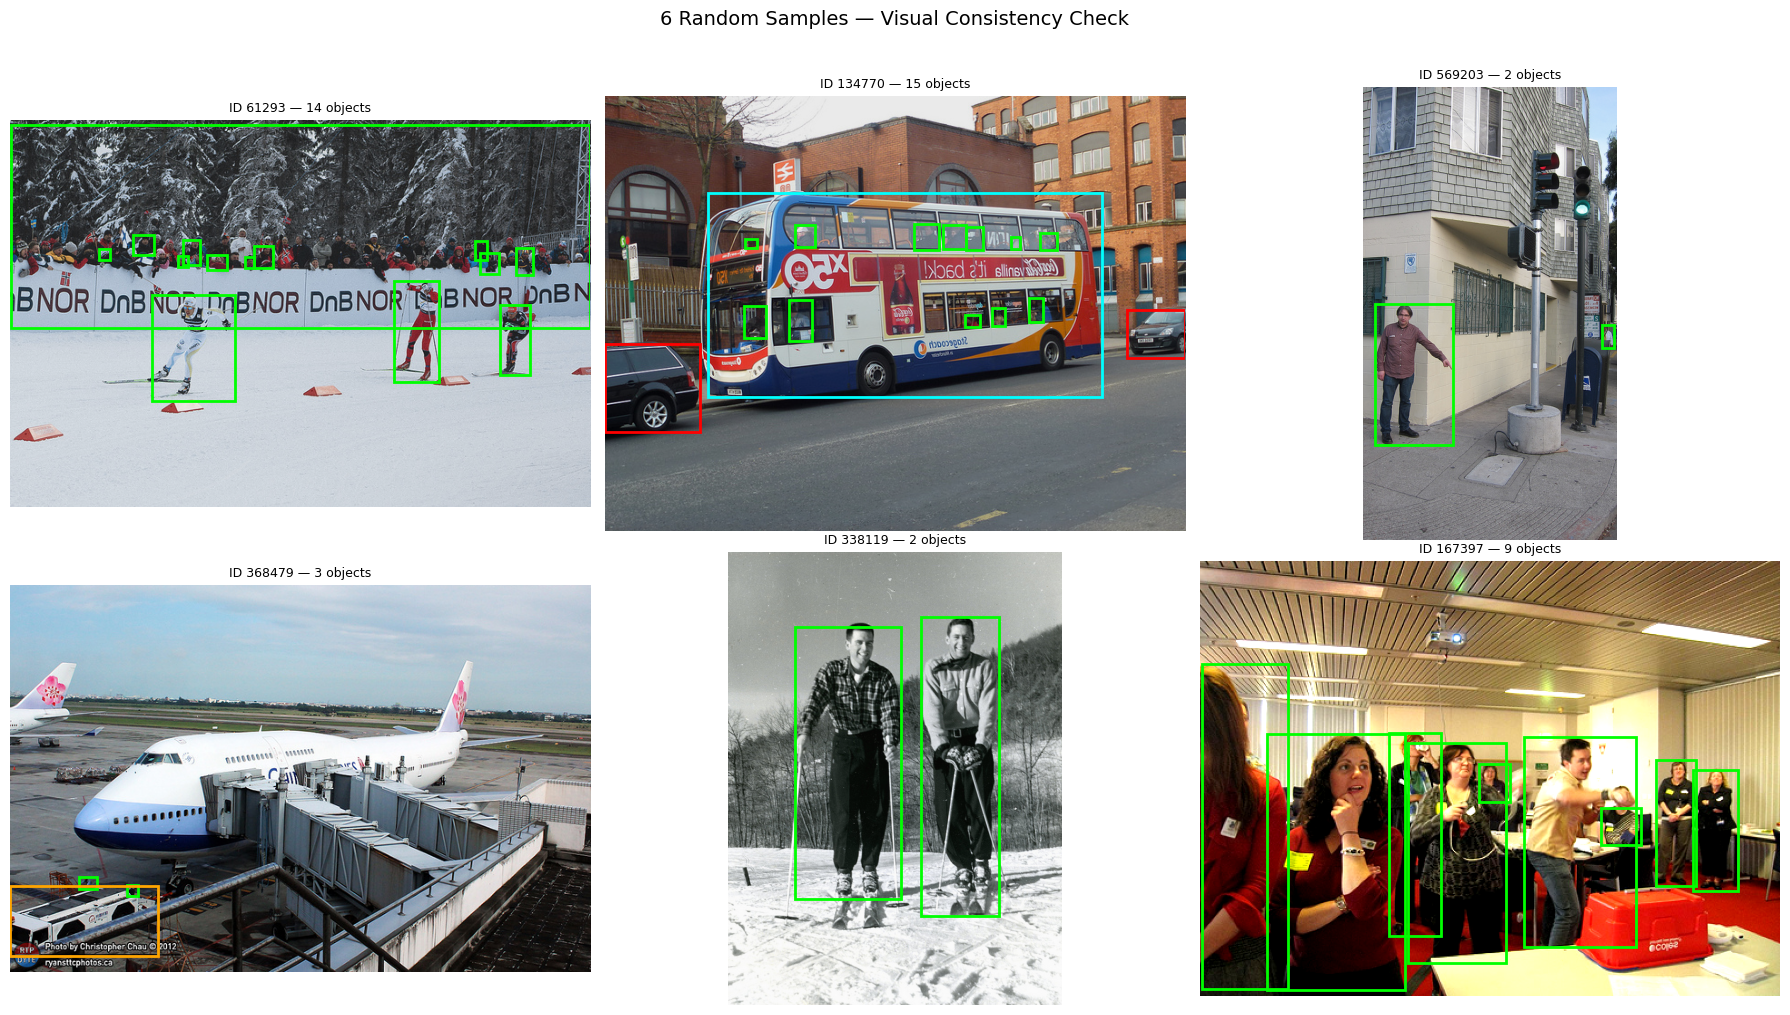

In [4]:
# Visual check across 6 random samples to confirm consistency
import random

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sample_indices = random.sample(range(len(ds)), 6)

for ax, idx in zip(axes, sample_indices):
    img, tgt = ds[idx]
    img_disp = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_disp)

    for box, label in zip(tgt["boxes"], tgt["labels"]):
        x1, y1, x2, y2 = box.tolist()
        name  = LABEL_TO_NAME[label.item()]
        color = CLASS_COLORS.get(name, "white")
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"ID {tgt['image_id'].item()} — {len(tgt['boxes'])} objects", fontsize=9)
    ax.axis("off")

plt.suptitle("6 Random Samples — Visual Consistency Check", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [5]:
loader = DataLoader(ds, batch_size=2, shuffle=True, collate_fn=collate_fn)
imgs, tgts = next(iter(loader))

print("=== Batch Inspection ===")
print(f"Batch size              : {len(imgs)}")
print(f"Image 0 shape           : {imgs[0].shape}")
print(f"Image 1 shape           : {imgs[1].shape}")
print(f"Shapes same?            : {imgs[0].shape == imgs[1].shape}  ← expected: may differ")
print(f"Image 0 — num boxes     : {len(tgts[0]['boxes'])}")
print(f"Image 1 — num boxes     : {len(tgts[1]['boxes'])}")
print(f"Image 0 — labels        : {[LABEL_TO_NAME[l.item()] for l in tgts[0]['labels']]}")
print(f"Image 1 — labels        : {[LABEL_TO_NAME[l.item()] for l in tgts[1]['labels']]}")

=== Batch Inspection ===
Batch size              : 2
Image 0 shape           : torch.Size([3, 375, 500])
Image 1 shape           : torch.Size([3, 428, 640])
Shapes same?            : False  ← expected: may differ
Image 0 — num boxes     : 2
Image 1 — num boxes     : 4
Image 0 — labels        : ['bicycle', 'bicycle']
Image 1 — labels        : ['person', 'person', 'person', 'person']


In [6]:
# Count how many instances of each class exist in first 500 images
# Helps spot class imbalance early

from collections import Counter

print("Counting class distribution across first 500 samples...")
counter = Counter()

for i in range(min(500, len(ds))):
    _, tgt = ds[i]
    for label in tgt["labels"].tolist():
        counter[LABEL_TO_NAME[label]] += 1

# Sort by count descending
sorted_counts = sorted(counter.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'Class':<15} {'Count':>8}  {'Bar'}")
print("-" * 45)
total = sum(counter.values())
for cls, count in sorted_counts:
    bar = "█" * int(40 * count / total)
    print(f"{cls:<15} {count:>8}  {bar}")
print(f"\n{'TOTAL':<15} {total:>8}")

Counting class distribution across first 500 samples...

Class              Count  Bar
---------------------------------------------
person              1891  ███████████████████████████████
car                  336  █████
truck                 60  
bicycle               53  
motorcycle            46  
bus                   43  

TOTAL               2429


In [7]:
# Automated checklist — all should print ✅

checks = {
    "Dataset loaded"         : len(ds) > 0,
    "Image is float32"       : image.dtype == torch.float32,
    "Image has 3 channels"   : image.shape[0] == 3,
    "Boxes in xyxy format"   : (target["boxes"][:, 2] > target["boxes"][:, 0]).all().item()
                                if len(target["boxes"]) > 0 else True,
    "Labels are 1-based"     : (target["labels"] >= 1).all().item()
                                if len(target["labels"]) > 0 else True,
    "DataLoader batch works" : len(imgs) == 2,
    "collate_fn works"       : isinstance(imgs, list) and isinstance(tgts, list),
}

print("=== Step 1 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("🎉 All checks passed — ready for Step 2 (Backbone)!")
else:
    print("⚠️  Fix the failing checks before moving on.")

=== Step 1 Checklist ===

  ✅  Dataset loaded
  ✅  Image is float32
  ✅  Image has 3 channels
  ✅  Boxes in xyxy format
  ✅  Labels are 1-based
  ✅  DataLoader batch works
  ✅  collate_fn works

🎉 All checks passed — ready for Step 2 (Backbone)!
